In [1]:
import pandas as pd
#import ipynb
#import marchMadnessPredictorFunctions as functions
%run ./marchMadnessPredictorFunctions.ipynb as functions
import random



In [2]:
#readcsv
teamRatings = pd.read_csv("marchMadnessData/RPPF Ratings.csv")
year = 2026
teamRatings2026 = teamRatings[teamRatings["YEAR"]==year]
#create pyth baseline strength column
teamRatings2026["PYTH STRENGTH"] =calc_strength_pyth(teamRatings2026['RADJ O'], teamRatings2026['RADJ D'])
teamA = "Alabama"
result = teamRatings2026.loc[teamRatings['TEAM'] == teamA, 'PYTH STRENGTH'].values[0]
print(result)

0.9115402858178578


In [3]:
class Team:
    
    def __init__(self,name,score):
        self.name = name 
        self.score = score

    def strength(self, offense, defense):
        offsense.self = offense
        defense.self = defense
        score = functions.calc_strength_pyth(offense, defense)

In [4]:
def create_teams(teams):
    myList = []
    for team in teams:
        score = teamRatings2026.loc[teamRatings2026['TEAM'] == team, 'PYTH STRENGTH'].values[0]
        team = Team(team, score)
        myList.append(team)
    return myList

In [5]:
import random
class Game: 
    def __init__(self, teamA, teamB):
        self.teamA = teamA
        self.teamB = teamB

    def calc_win_prob(self):
        #log-5 formula
        probBPoor = 1-self.teamB.score
        #pythA = prob A plays well
        numerator = (self.teamA.score*probBPoor) #prob A plays well and B plays poorly
        denominator = self.teamA.score + self.teamB.score - (2 * self.teamA.score * self.teamB.score) #all possible outcomes
        return numerator / denominator
    
    def simulate_game(self):
       #create a random roll
        randomRoll = random.random()

        if(randomRoll < self.calc_win_prob()):
            #print(f"Prediction: {self.teamA.name} beats {self.teamB.name} at original probability of {self.calc_win_prob(): .2%}")
            return self.teamA
        else:
            #print(f"Predicting upset: {self.teamB.name} beats {self.teamA.name} at original probability of {(1-(self.calc_win_prob())):.2%}")
            return self.teamB

In [6]:
def simulate_round(teamList):
    winner = []
    for i in range(0,len(teamList), 2):
        teamA = teamList[i]
        teamB = teamList[i+1]
        #score1 = teamRatings2026.loc[teamRatings2026['TEAM'] == teamAName, 'PYTH STRENGTH'].values[0]
        #score2 = result = teamRatings2026.loc[teamRatings2026['TEAM'] == teamBName, 'PYTH STRENGTH'].values[0]
        #teamA = Team(teamAName, score1)
        #teamB = Team(teamBName, score2)
        game = Game(teamA, teamB)
        result = game.simulate_game()
        winner.append(result)
        
    return winner
        

In [7]:
#winner = simulate_round(["Duke", "Alabama", "Michigan", "Virginia"])

#simulate tournament

myList = ["Duke", "Alabama", "Michigan", "Virginia"]
teamList = (create_teams(myList))

def tournament_predictor (teamList):
    while len(teamList)>1:
        #print("Simulating round of ", len(teamList))
        teamList = simulate_round(teamList)
    return teamList
#print(list.name)

In [8]:
#test tournament predictor
winner = tournament_predictor(teamList)
for i in winner:
    print(i.name)
print(winner[0].name)

Alabama
Alabama


In [9]:
#run monte carlo simulations
import copy

#check if there's a way to determine how many simulations should be run
def monte_carlo(teams, num_sims = 10000):
    winner_dict = {}
    for i in range (num_sims):
        teamsCopy = copy.deepcopy(teams)
        winner = tournament_predictor(teamsCopy)[0].name
        winner_dict[winner] = winner_dict.get(winner, 0)+1
    winning_prob = {}
    for team in winner_dict:
        winning_prob[team] = winner_dict.get(team, 0.000001)/num_sims
    sortedWinningProb = dict(sorted(winning_prob.items(), key = lambda item: item[1], reverse = True))
    return sortedWinningProb



In [10]:
#test monte carlo
testList = [
    "Illinois", "Iowa",          # South Regional Final
    "Arizona", "Purdue",         # West Regional Final
    "Michigan", "Tennessee",     # Midwest Regional Final
    "Connecticut", "Duke"              # East Regional Final
]
teamList =create_teams(testList)
winners = monte_carlo(teamList, 10000)
for team, prob in winners.items():
    print(f"{team}: {prob: .2%}")

Duke:  29.34%
Arizona:  26.42%
Michigan:  23.62%
Illinois:  8.81%
Purdue:  5.30%
Connecticut:  3.11%
Tennessee:  2.24%
Iowa:  1.16%


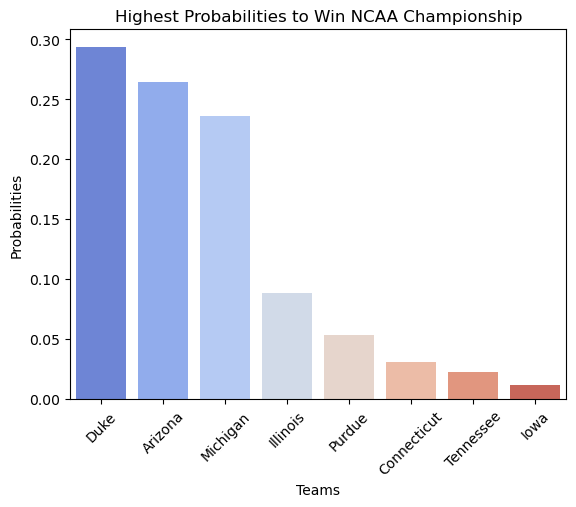

In [26]:
#plot results
import seaborn as sns
import matplotlib.pyplot as plt

plot= sns.barplot(
    x = list(winners.keys()),
    y = list(winners.values()),
    hue = winners.keys(),
    palette = 'coolwarm'
)
plt.xticks(rotation = 45)
plt.title("Highest Probabilities to Win NCAA Championship")
plt.ylabel("Probabilities")
plt.xlabel("Teams")
plt.show()


In [12]:
#test classes
team1 = Team("Duke", 0.92)
team2 = Team("UConn", 0.85)
game1 = Game(team1, team2)

print(game1.teamA.name)

winner = game1.simulate_game()
print(f"The winner is {winner.name}")

Duke
The winner is Duke


In [13]:
teamRatings = pd.read_csv("marchMadnessData\RPPF Ratings.csv")
teamRatings.columns

<>:1: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<>:1: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
C:\Users\morga\AppData\Local\Temp\ipykernel_2444\2800587131.py:1: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
  teamRatings = pd.read_csv("marchMadnessData\RPPF Ratings.csv")


Index(['YEAR', 'TEAM NO', 'TEAM', 'SEED', 'ROUND', 'RPPF RATING RANK',
       'RPPF RATING', 'NPB RATING RANK', 'NPB RATING', 'RADJ O RANK', 'RADJ O',
       'RADJ D RANK', 'RADJ D', 'RADJ EM RANK', 'RADJ EM', 'R PACE RANK',
       'R PACE', 'R SOS RANK', 'R SOS', 'STROE RANK', 'STROE', 'STRDE RANK',
       'STRDE', 'STRT+ RANK', 'STREM RANK', 'STREM', 'STREM RANK 2'],
      dtype='str')

In [14]:
#start with single season
year = 2026
teamRatings2026 = teamRatings[teamRatings["YEAR"]==year]

print(teamRatings2026["RADJ O"].head)
teamRatings2026["RADJ D"].head

<bound method NDFrame.head of 0     118.4
1     130.2
2     128.8
3     129.3
4     126.4
      ...  
63    120.1
64    120.6
65    123.0
66    126.7
67    112.1
Name: RADJ O, Length: 68, dtype: float64>


<bound method NDFrame.head of 0     106.1
1     103.7
2      90.2
3     102.3
4     102.6
      ...  
63    102.5
64    100.6
65     95.5
66    101.9
67    110.4
Name: RADJ D, Length: 68, dtype: float64>

In [15]:
#create pyth baseline strength column
teamRatings2026["PYTH STRENGTH"] =calc_strength_pyth(teamRatings2026['RADJ O'], teamRatings2026['RADJ D'])
teamA = "Alabama"
result = teamRatings2026.loc[teamRatings['TEAM'] == teamA, 'PYTH STRENGTH'].values[0]
print(result)



0.9115402858178578


In [16]:
#class test
teamA = Team("Duke", 0.99)